In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

In [2]:
plt.style.use('style.mplstyle')
sns.set_context('talk', font_scale=1.0)
fig_folder = os.path.abspath("figures/")

# 0. Load Shapley Values

In [3]:
# only select a single dataset
dataset = 'esol_delaney'
# consider dummy atoms
remove_dummies = False

rename_datasets = {'esol_delaney': 'ESOL',
                   'solubility_mobley': 'Mobley',
                   }

files = ['./rf_regression_solubility/df_explanation.pkl']
df_sol = pd.concat((pd.read_pickle(sol_file) for sol_file in files))

df_sol = df_sol.loc[df_sol.dataset == dataset]
df_sol['dataset'] = df_sol['dataset'].replace(rename_datasets)

# 1. Get List of Fragments and their Shapley Values Across all Splits

In [4]:
from rdkit.Chem import MolFromSmiles, MolToSmiles, FragmentOnBRICSBonds, GetMolFrags
from rdkit.Chem import RWMol, SanitizeMol
from rdkit.Chem import ReplaceSubstructs, RemoveAllHs

def remove_isotope_information_for_dummy_atoms(m):
    '''
        Removes the isotope information from dummy atoms (denoted as *). Does nothing if molecule does not have a dummy atom

        input:
            m : rdkit.Mol, Molecule

        output:
            rdkit.Mol, Molecule without isotope information at dummy atoms
    '''
    for at in m.GetAtoms():
        if at.GetSymbol() == '*':
            at.SetIsotope(0)
    return m

def remove_dummy_atoms(m):
    '''
        Removed dummy atoms (denoted as *) from molecule. Works by replacing dummy atom(s) with hydrogen(s)

        input:
            m : rdkit.Mol, Molecule
        
        output:
            rdkit.Mol, sanitized Molecule without dummy atom(s)
    '''
    dummy = MolFromSmiles('*')
    m_cleaned = ReplaceSubstructs(m, dummy, MolFromSmiles('[H]'), replaceAll=True)[0]
    return RemoveAllHs(m_cleaned, sanitize=True)

def get_BRICS_fragments_as_SMILES(smiles, remove_dummies=False):
    '''
        Fragments a SMILES using BRICS and returns the fragments as a list of SMILES. First, turns the input SMILES into rdkit.Mol.
        Followed by fragmenting using BRICS and removal of isotope information on the cleavage sites.

        input:
            smiles: str, SMILES string of molecule to fragment
            remove_dummies: bool, default False, flag to remove dummy atoms from fragments

        output:
            List[str] list of SMILES without isotope information and depending on remove_dummies with or without dummy atoms
    '''
    mol = MolFromSmiles(smiles)
    frag_ = FragmentOnBRICSBonds(mol)
    frags = GetMolFrags(frag_,
                        asMols=True)
    frags_cleaned = [remove_isotope_information_for_dummy_atoms(m) for m in frags]
    if remove_dummies:
        frags_cleaned = [remove_dummy_atoms(m) for m in frags_cleaned]
        
    return [MolToSmiles(m) for m in frags_cleaned]

In [5]:
df_sol['fragments'] = df_sol.smiles.apply(lambda x: get_BRICS_fragments_as_SMILES(x, remove_dummies=remove_dummies))

In [6]:
# get the values of the Explainer as a list (currently only available as dict)
df_sol['fragExplainer_shapley_values'] = df_sol.fragExplainer_result.apply(lambda x: list(x.values()))
# create a dataframe of all fragments (contains duplicates) and the corresponding Shapley Value
df_fragments = df_sol[['fragments', 'fragExplainer_shapley_values']].explode(['fragments', 'fragExplainer_shapley_values'], ignore_index=True)

In [7]:
df_fragments = df_fragments.groupby('fragments').agg([len, 'mean', 'std', list]) # will throw warning veacuse of error when calculating std for a single measurement
df_fragments = df_fragments.reset_index() # reset so that 'fragments' is a column again and no longer the index
df_fragments.columns = [col[0] if col[1]=='' else col[1] for col in df_fragments.columns.values] # rename, choose 'fragments' for first column, for the other simply len, mean, std
df_fragments

,fragments,len,mean,std,list
0,*=C(C(=*)c1ccc(O)cc1)c1ccc(O)cc1,1,-0.15053,NaN,[-0.15052999999999983]
1,*=C(C)C,8,0.150819,0.269925,"[0.6644069047619048, 0.26684345238095214, 0.23..."
2,*=C(C)OP(=O)(OC)OC,1,0.79678,NaN,[0.7967799999999998]
3,*=C(C)OP(=S)(NCC)OC,1,-1.031887,NaN,[-1.0318866666666668]
4,*=C(C=O)CC,1,0.814102,NaN,[0.8141025]
...,...,...,...,...,...
994,c1ccoc1,1,-0.26064,NaN,[-0.2606399999999991]
995,c1ccsc1,1,-0.19027,NaN,[-0.1902699999999986]
996,c1cnc2c(c1)ccc1ncccc12,1,-3.079327,NaN,[-3.0793274999999998]
997,c1cnc2ncncc2n1,1,0.52894,NaN,[0.5289400000000005]


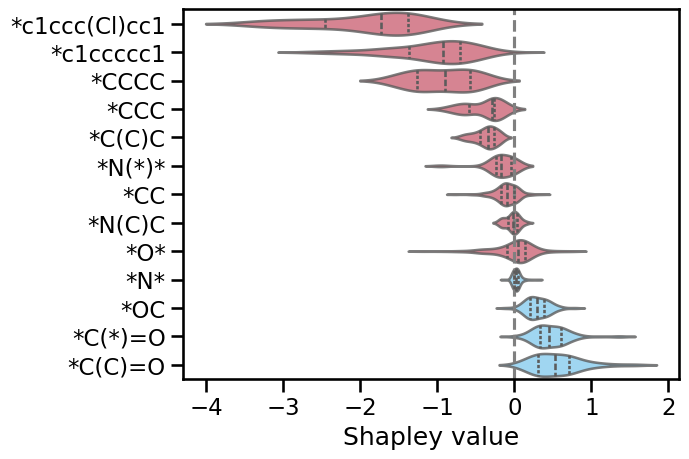

In [29]:
# now get the smiles to consider
min_n = 20

# get list of SMILES of the fragments that appear at least min_n times
smiles_to_consider = df_fragments.query('len >= @min_n').fragments.to_list()
# get their mean values to order them in the plot afterwards
mean_vals = df_fragments.query('fragments in @smiles_to_consider')['mean'].values
sort_idx = np.argsort(mean_vals)
sm_ordered = np.array(smiles_to_consider)[sort_idx]

fig, axs = plt.subplots(1, 1)
axs.axvline(x=0, color='gray', ls='--') # line to indicate change from positive to negative influence

sns.violinplot(df_fragments.query('len >= @min_n').explode('list'), # need to explode to get the list untangled
               x='list',
               y='fragments',
               inner='quart',
               density_norm='width',
               order=sm_ordered, # order them correctly
               ax=axs
               )

# color the violins individually based on whether their average contribution is above zero or not
col_negative = sns.color_palette()[0]
col_positive = sns.color_palette()[4]
color_list = list(col_negative if mv < 0 else col_positive for mv in mean_vals[sort_idx])
for violin, color in zip(axs.collections, color_list):
    violin.set_facecolor(color)
    violin.set_alpha(0.8)

# fix labels
axs.set_ylabel('')
axs.set_xlabel('Shapley value')

fig.savefig(os.path.join(fig_folder, f'2_{dataset}_violin_min_{min_n}.pdf'), 
            bbox_inches='tight',
            )

In [9]:
# need to check expected value if we can actually compare across different splits
df_sol.fragExplainer_expected_value.unique(), df_sol.fragExplainer_expected_value.agg(['mean', 'std'])

(array([-0.97902, -1.2304 , -1.27492, -1.48401, -1.0454 ]),
 mean   -1.202750
 std     0.178907
 Name: fragExplainer_expected_value, dtype: float64)

# 2. Molecular "Optimization": Demonstrate Additivity

In [10]:
# need to use only a single split now
split = 0

In [11]:
# need to get train/test instances now
df_perf = pd.read_pickle('rf_regression_solubility/df_performance.pkl')
df_all = pd.read_csv(f'../0_datasets/regression/{dataset}.csv')
df_expl = pd.read_pickle('rf_regression_solubility/df_explanation.pkl').query('dataset == @dataset and split == @split')

In [12]:
train_indices = df_perf.loc[(df_perf.split == split) & (df_perf.dataset == dataset)].iloc[0].train_index
train_smiles = df_all.nonstereo_aromatic_smiles.to_numpy()[train_indices]

## 2.1 Get Shapley Values per Fragment
Same as above but this time only for the specific split 

In [13]:
df_expl['fragments'] = df_expl.smiles.apply(lambda x: get_BRICS_fragments_as_SMILES(x, remove_dummies=remove_dummies))

In [14]:
# get the values of the Explainer as a list (currently only available as dict)
df_expl['fragExplainer_shapley_values'] = df_expl.fragExplainer_result.apply(lambda x: list(x.values()))
# create a dataframe of all fragments (contains duplicates) and the corresponding Shapley Value
df_frag = df_expl[['fragments', 'fragExplainer_shapley_values']].explode(['fragments', 'fragExplainer_shapley_values'], ignore_index=True)

In [15]:
df_frag = df_frag.groupby('fragments').agg([len, 'mean', 'std']) # will throw warning veacuse of error when calculating std for a single measurement
df_frag = df_frag.reset_index() # reset so that 'fragments' is a column again and no longer the index
df_frag.columns = [col[0] if col[1]=='' else col[1] for col in df_frag.columns.values] # rename, choose 'fragments' for first column, for the other simply len, mean, std
df_frag

,fragments,len,mean,std
0,*=C(C)OP(=S)(NCC)OC,1,-1.031887,NaN
1,*=C(CC)c1ccc(O)cc1,2,-0.87462,0.000000
2,*=CC,1,-0.35005,NaN
3,*=CC=O,1,1.05707,NaN
4,*C(*)=O,17,0.391213,0.186183
...,...,...,...,...
258,c1ccc2ocnc2c1,1,-0.72738,NaN
259,c1ccccc1,1,-0.39233,NaN
260,c1cnc2c(c1)ccc1ncccc12,1,-3.079327,NaN
261,c1cnc2ncncc2n1,1,0.52894,NaN


In [16]:
min_appearance = 3
df_frag = df_frag.loc[df_frag['len'] >= min_appearance]
df_frag.shape

(24, 4)

In [17]:
def filter_n_attachment(smiles, n):
    '''
        Filter for number of attachment points in fragment  (equal to number of dummy atoms)

        input:
            smiles: SMILES string of molecule to check for number of attachment points
            n: number of attachments points
        ouput:
            bool, True if number of attachment points is equal to n, else False
    '''
    if smiles.count('*') == n:
        return True
    else:
        return False
# filter out fragments with more than one attachment points

df_frag = df_frag.loc[df_frag.fragments.apply(lambda x: filter_n_attachment(x, n=1))]
df_frag

,fragments,len,mean,std
9,*C(=O)CC,3,0.323136,0.144545
13,*C(C)(C)C,4,-0.891146,0.244429
15,*C(C)=O,8,0.477257,0.272269
16,*C(C)C,9,-0.447563,0.100787
22,*C(F)(F)F,4,-0.678875,0.150882
23,*C(N)=O,4,0.783139,0.013065
48,*CC,29,-0.085608,0.120154
56,*CC=C,6,-0.308031,0.076813
57,*CCC,4,-0.778136,0.082257
60,*CCCC,6,-1.172231,0.308530


## 2.2 Define Core and Assemble Combinations

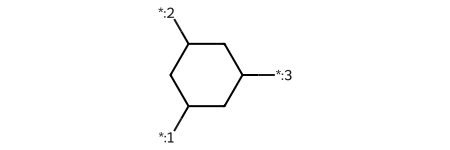

In [18]:
# choose an appropriate core
n_attach_smiles = {1: 'C1C([*:1])CCC(C(C)C)C1(O)',
                   2: 'C1CC([*:1])CC([*:2])C1',
                   3: 'C1([*:3])CC([*:1])CC([*:2])C1',
                   }

n_attach = 3
core_smiles = n_attach_smiles[n_attach]
core_mol = MolFromSmiles(core_smiles)
attachments_symmetrically_equivalent = {1: False,
                                        2: True,
                                        3: True}[n_attach]
core_mol

In [19]:
# generate list of tuples containing the substituent ant the mean and std contribution
frag_mean = [(smiles, mean) for smiles, mean in zip(df_frag.fragments, df_frag['mean'], )]

In [20]:
from itertools import product, combinations_with_replacement
from rdkit.Chem import molzip, RWMol

# choose correct iterator depending on symmetry
if attachments_symmetrically_equivalent:
    iterator = combinations_with_replacement(frag_mean, n_attach)
else:
    iterator = product(frag_mean, repeat=n_attach)

def add_attachment_point_number_to_connection_point(smiles, number):
    return smiles.replace('*', f'[*:{number}]')

result_list = []

# iterate over all combinations
for out in iterator:
    smiles = [i[0] for i in out]
    means = [i[1] for i in out]
    smiles_processed = [add_attachment_point_number_to_connection_point(sm, idx+1) for idx, sm in enumerate(smiles)] # add correct attachment point number (+1 since attachment points start numbering from 1)
    tmp_mol = RWMol(core_mol) # create new mol, editable
    [tmp_mol.InsertMol(MolFromSmiles(sm)) for sm in smiles_processed] # insert all fragments
    tmp_mol = molzip(tmp_mol) # zip it together
    result_list.append((MolToSmiles(tmp_mol, canonical=True), means))

In [21]:
df_combs = pd.DataFrame({'smiles': [i[0] for i in result_list],
                         'means': [i[1] for i in result_list],
                         })
df_combs.shape

(680, 2)

In [22]:
# remove duplicates
df_combs = df_combs.drop_duplicates(subset='smiles')
# sum mean contribution
df_combs['sum_mean_attributions'] = df_combs.means.apply(sum)
df_combs.shape

(680, 3)

In [23]:
# check if created molecules are in training set
df_combs = df_combs.query('smiles not in @train_smiles')
df_combs.shape

(680, 3)

## 2.3 Load Model and get Predictions

In [24]:
from pickle import load
with open(f'rf_regression_solubility/models/model_rfr_{dataset}_split_{split}.pkl', 'rb') as f:
    rfr = load(f)

In [25]:
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

mfpgen = GetMorganGenerator(radius=2,
                            fpSize=2048,
                            )
fps = np.stack([mfpgen.GetFingerprintAsNumPy(MolFromSmiles(sm)) for sm in df_combs.smiles])
fps.shape

(680, 2048)

In [26]:
df_combs['prediction'] = rfr.predict(fps)

In [27]:
df_combs

,smiles,means,sum_mean_attributions,prediction
0,CCC(=O)C1CC(C(=O)CC)CC(C(=O)CC)C1,"[0.3231355555555556, 0.3231355555555556, 0.323...",0.969407,-1.94343
1,CCC(=O)C1CC(C(=O)CC)CC(C(C)(C)C)C1,"[0.3231355555555556, 0.3231355555555556, -0.89...",-0.244875,-2.13912
2,CCC(=O)C1CC(C(C)=O)CC(C(=O)CC)C1,"[0.3231355555555556, 0.3231355555555556, 0.477...",1.123528,-1.92133
3,CCC(=O)C1CC(C(=O)CC)CC(C(C)C)C1,"[0.3231355555555556, 0.3231355555555556, -0.44...",0.198708,-2.19503
4,CCC(=O)C1CC(C(=O)CC)CC(C(F)(F)F)C1,"[0.3231355555555556, 0.3231355555555556, -0.67...",-0.032604,-2.16103
...,...,...,...,...
675,COC1CC(c2ccccc2)CC(c2ccccc2)C1,"[0.3691576736694679, -1.274353023018703, -1.27...",-2.179548,-2.36356
676,CSC1CC(SC)CC(SC)C1,"[-0.11590916666666616, -0.11590916666666616, -...",-0.347727,-2.68234
677,CSC1CC(SC)CC(c2ccccc2)C1,"[-0.11590916666666616, -0.11590916666666616, -...",-1.506171,-2.47171
678,CSC1CC(c2ccccc2)CC(c2ccccc2)C1,"[-0.11590916666666616, -1.274353023018703, -1....",-2.664615,-2.47171


[10:56:10] WARNING: not removing hydrogen atom without neighbors


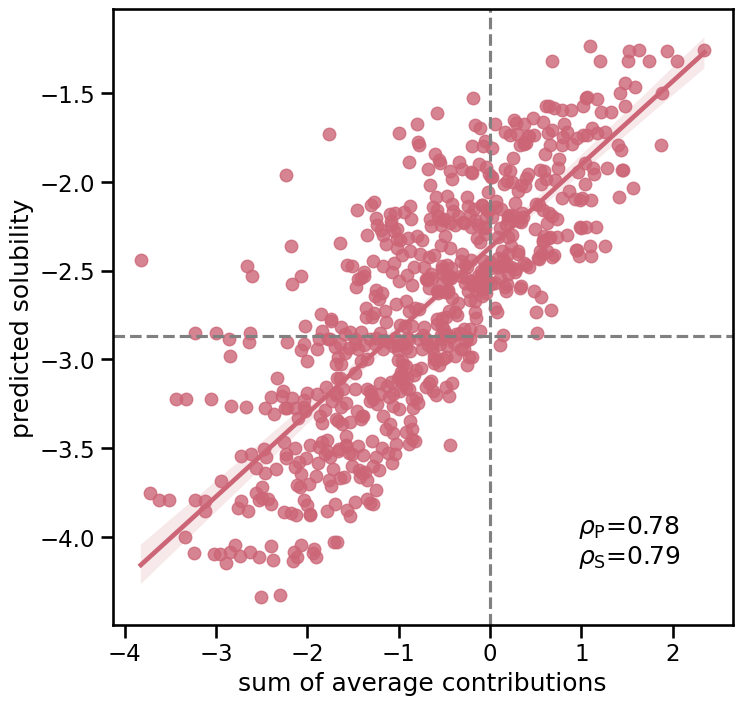

In [28]:
from scipy.stats import pearsonr, spearmanr


fig, axs = plt.subplots(1, 1, figsize=(8, 8))

sns.regplot(data=df_combs,
            x='sum_mean_attributions',
            y='prediction',
            ax=axs)
axs.set_xlabel('sum of average contributions')
axs.set_ylabel('predicted solubility')

# add default value of no substituents
core_hydrogen = remove_dummy_atoms(core_mol)
fp_core_hydrogens = mfpgen.GetFingerprintAsNumPy(core_hydrogen)
pred_core_hydrogens = rfr.predict(fp_core_hydrogens.reshape(1, -1))[0]

axs.axhline(pred_core_hydrogens, color='grey', ls='--')
axs.axvline(0, color='gray', ls='--')

# add statistics
pearson_stat = pearsonr(df_combs.sum_mean_attributions, df_combs.prediction)
spearman_stat = spearmanr(df_combs.sum_mean_attributions, df_combs.prediction)

axs.text(x=0.75,
         y=0.15,
         s='$\\rho_{\\mathrm{P}}$'+f'={pearson_stat.statistic:.2f}',
         transform=axs.transAxes,
         ha='left')
axs.text(x=0.75,
         y=0.10,
         s='$\\rho_{\\mathrm{S}}$'+f'={spearman_stat.statistic:.2f}',
         transform=axs.transAxes,
         ha='left')

fig.savefig(os.path.join(fig_folder, f'2_{dataset}_opt_split_{split}_n_{n_attach}.pdf'), 
            bbox_inches='tight',
            )